# Labs 2 and 3 — Annotated Arrhythmia Worked Example

This notebook combines the UCI Arrhythmia worked reference, learner tasks, and Assessment 1 preparation activities from Labs 2 and 3.

## How to use this notebook

1. Select a Python kernel in Jupyter.
2. Run the cells in order the first time. Each code task is kept in its own cell so you can return to it and experiment.
3. Read **What the result means** after each task, then answer the nearby **Your task** prompt in your own words.
4. Restart the kernel and use **Run All** before submission.

Short comments explain each code block. Comments beginning **Added**, **Deviation**, or **Local adaptation** identify code that differs from the supplied script, explain why it was included, and state whether it is necessary or optional.

The Python and Jupyter Cursor extensions are required. The analysis uses `pandas`, `numpy`, `matplotlib`, and `scipy`. The first code cell installs only packages that are missing from the selected kernel.

> **Learning boundary:** the worked Arrhythmia calculations and model interpretations are provided as a learning reference. Your own responses, Assessment group details, dataset approval, Canvas submission, and results for your future dataset must not be invented.


## Setup — Check the Python packages

This cell checks the active kernel and installs only missing packages. This setup is **added beyond the supplied script** to make the notebook easier to run; it is useful when packages are missing but is not part of the analysis. `sqlite3`, `pathlib`, `tempfile`, and `time` are included with Python.


In [30]:
# Check and install only missing packages.
# Added beyond the lab script: useful setup, but not part of the analysis.
import importlib.util
import subprocess
import sys

required_packages = ["pandas", "numpy", "matplotlib", "scipy"]
missing_packages = [
    package
    for package in required_packages
    if importlib.util.find_spec(package) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *missing_packages]
    )
else:
    print("All required packages are already installed.")

# Standard-library tools used later.
import sqlite3
import tempfile
import time
from pathlib import Path

# Analysis and plotting libraries.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# A fixed seed makes the later jitter plot reproducible.
rng = np.random.default_rng(707)
pd.set_option("display.max_columns", 20)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)


All required packages are already installed.
Python: 3.14.4
pandas: 3.0.5


**What the result means:** the version lines identify the software that produced the outputs. If packages were installed, restart the kernel only if an import error appears. No additional plotting or database extension is required.


# Lab 2 — Part A: Acquire, inspect, clean, ETL and ELT

## Steps 1–2 — Check suitability and document the dataset

The [UCI Arrhythmia Dataset](https://archive.ics.uci.edu/dataset/5/arrhythmia) contains demographic and ECG-derived measurements for **452 patient records**. It has **279 input features** and one diagnosis class, giving 280 raw columns.

### Suitability check

| Check | Result |
|---|---|
| Tabular, alpha-numeric | Yes — delimited categorical, integer, and real-valued measurements |
| Feature count | 279 inputs plus one diagnosis class; 280 raw columns |
| Enough records for a first look? | Yes — 452 records for inspection, cleaning, visualisation, and introductory analysis |

### Dataset documentation

| Field | Answer |
|---|---|
| Dataset name | UCI Arrhythmia Dataset (`arrhythmia.data`) |
| Source | https://archive.ics.uci.edu/dataset/5/arrhythmia |
| Direct file | https://archive.ics.uci.edu/static/public/5/arrhythmia.zip |
| Access date in instructions | 21 July 2026 |
| Licence | Creative Commons Attribution 4.0 International (CC BY 4.0) |
| Structure | Delimited, tabular alpha-numeric demographic and ECG data |
| Size | 452 records; 279 inputs plus one diagnosis class |
| Original collection | Patient demographics and 12-lead ECG measurements; cardiologist classifications were the reference standard |
| Privacy | Patient names and identification numbers were removed |

**How the data was collected:** each row represents one patient whose age, sex, height, weight, heart rate, ECG timing intervals, waveform shapes, amplitudes, and measurements across 12 ECG leads were recorded. A cardiologist assigned the normal or arrhythmia class used as the reference result. Names and identification numbers were removed. Some ECG values are missing, but the documentation does not explain why each individual measurement was unavailable.

> **Assessment form note:** paste the complete plain-text URL `https://archive.ics.uci.edu/dataset/5/arrhythmia` into the MS/Canvas form rather than only displaying linked words such as “Arrhythmia - UCI Machine Learning Repository.”

**Your task:** record the problem, suitability checks, source, licence, collection method, and full source URL in your own notes.


## Step 3 — Load the Arrhythmia data

The dataset is stored locally at `arrhythmia/arrhythmia.data`. The raw file has no header row, so `header=None` gives the columns temporary numeric labels. Missing measurements are written as `?`, which `na_values="?"` converts to Pandas missing values.

Keep the `arrhythmia` folder beside this notebook so the relative path continues to work.


In [31]:
# Load the local file with no header row.
# Local adaptation: the supplied data is inside the arrhythmia folder.
import pandas as pd

df = pd.read_csv(
    "arrhythmia/arrhythmia.data",
    header=None,       # Use temporary numeric column names.
    na_values="?"     # Convert ? to missing values.
)

print("Raw shape:", df.shape)
display(df.head())


Raw shape: (452, 280)


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


### Assign meaningful column names

The first 15 columns contain the main demographic and ECG timing/angle measurements. The final column is the diagnosis class. The remaining waveform columns keep their numeric labels because the lab does not analyse each one individually.


In [32]:
# Name the first 15 fields and the final target.
df.columns = [
    "age", "sex", "height", "weight",
    "qrs_duration", "pr_interval", "qt_interval",
    "t_interval", "p_interval", "qrs_angle",
    "t_angle", "p_angle", "qrst_angle",
    "j_angle", "heart_rate"
] + list(df.columns[15:-1]) + ["class"]

print(df.columns[:15])
print(df.columns[-3:])
display(df.head())

# Added safeguard: stops on the wrong dataset; optional but useful.
assert df.shape == (452, 280), "Expected 452 rows and 280 columns."


Index(['age', 'sex', 'height', 'weight', 'qrs_duration', 'pr_interval',
       'qt_interval', 't_interval', 'p_interval', 'qrs_angle', 't_angle',
       'p_angle', 'qrst_angle', 'j_angle', 'heart_rate'],
      dtype='object')
Index([277, 278, 'class'], dtype='object')


,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,...,270,271,272,273,274,275,276,277,278,class
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


**What the result means:** the expected shape is `452 × 280`. One row is one patient's demographic and ECG record. The final `class` column is the cardiologist diagnosis: class 1 is normal, classes 2–15 are named arrhythmia groups, and class 16 is unclassified/other. The assertion deliberately stops the notebook if the wrong file is loaded.

**Your task:** record the raw shape and explain in your own words what one row and the final class column represent.


## Step 4 — Protect the raw data and describe its structure

A deep copy separates the supplied data from later transformations. `shape`, `dtypes`, `info()`, and `describe()` answer different questions: size, storage types, completeness/memory, and numeric summaries.


In [33]:
# Preserve an untouched raw copy.
df_original = df.copy(deep=True)

# Added check: detects later raw-data changes; optional safeguard.
raw_fingerprint = pd.util.hash_pandas_object(
    df_original, index=True
).sum()

print("Records:", df_original.shape[0])
print("Columns:", df_original.shape[1])
print("\nData-type counts:")
print(df_original.dtypes.value_counts())
print("\nDataFrame information:")
df_original.info()
print("\nSummary of numeric columns:")
display(df_original.describe())


Records: 452
Columns: 280

Data-type counts:
int64      155
float64    125
Name: count, dtype: int64

DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, age to class
dtypes: float64(125), int64(155)
memory usage: 988.9 KB

Summary of numeric columns:


,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,...,270,271,272,273,274,275,276,277,278,class
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,...,452.000000,452.000000,452.000000,452.000000,452.0,452.000000,452.000000,452.000000,452.000000,452.000000
mean,46.471239,0.550885,166.188053,68.170354,88.920354,155.152655,367.207965,169.949115,90.004425,33.676991,...,-0.278982,9.048009,-1.457301,0.003982,0.0,0.514823,1.222345,19.326106,29.473230,3.880531
std,16.466631,0.497955,37.170340,16.590803,15.364394,44.842283,33.385421,35.633072,25.826643,45.431434,...,0.548876,3.472862,2.002430,0.050118,0.0,0.347531,1.426052,13.503922,18.493927,4.407097
min,0.000000,0.000000,105.000000,6.000000,55.000000,0.000000,232.000000,108.000000,0.000000,-172.000000,...,-4.100000,0.000000,-28.600000,0.000000,0.0,-0.800000,-6.000000,-44.200000,-38.600000,1.000000
25%,36.000000,0.000000,160.000000,59.000000,80.000000,142.000000,350.000000,148.000000,79.000000,3.750000,...,-0.425000,6.600000,-2.100000,0.000000,0.0,0.400000,0.500000,11.450000,17.550000,1.000000
50%,47.000000,1.000000,164.000000,68.000000,86.000000,157.000000,367.000000,162.000000,91.000000,40.000000,...,0.000000,8.800000,-1.100000,0.000000,0.0,0.500000,1.350000,18.100000,27.900000,1.000000
75%,58.000000,1.000000,170.000000,79.000000,94.000000,175.000000,384.000000,179.000000,102.000000,66.000000,...,0.000000,11.200000,0.000000,0.000000,0.0,0.700000,2.100000,25.825000,41.125000,6.000000
max,83.000000,1.000000,780.000000,176.000000,188.000000,524.000000,509.000000,381.000000,205.000000,169.000000,...,0.000000,23.600000,0.000000,0.800000,0.0,2.400000,6.000000,88.800000,115.900000,16.000000


**What the result means:** the first four named columns are demographic variables; the timing, angle, heart-rate, and waveform columns are ECG-derived variables; `class` is the target. Missing values can cause otherwise numeric columns to be stored as floating point. A numeric summary can run without error and still be meaningless—for example, the mean of diagnosis codes would treat category numbers as measured quantities.

**Your task:** identify the demographic variables, ECG variables, and target column, then note any types that may need conversion or special treatment.


## Step 5 — Inspect quality before cleaning

Unusual does not automatically mean invalid. We inspect missingness, exact duplicate rows, important ranges, and diagnosis counts before deciding. BMI is calculated only as a consistency check; adult BMI categories must not be applied automatically to children.


In [34]:
# Count missing values in each column.
missing = df_original.isna().sum()
print("Columns containing missing values:")
print(missing[missing > 0].sort_values(ascending=False))

# Count fully repeated rows.
print("\nDuplicate rows:", df_original.duplicated().sum())

# Check important measurement ranges.
range_cols = ["age", "height", "weight", "heart_rate"]
print("\nMinimum and maximum values:")
display(df_original[range_cols].agg(["min", "max"]))

print("Patients per diagnosis class:")
print(df_original["class"].value_counts().sort_index())

# Flag unusual combinations for review, not deletion.
review_cols = ["age", "sex", "height", "weight", "class"]
records_to_review = df_original.loc[
    (df_original["age"] < 18)
    | (df_original["height"] < 120)
    | (df_original["height"] > 220)
    | (df_original["weight"] < 25),
    review_cols,
].sort_values(["age", "height", "weight"]).copy()
records_to_review["bmi"] = (
    records_to_review["weight"]
    / (records_to_review["height"] / 100) ** 2
)
display(records_to_review.round(2))


Columns containing missing values:
j_angle       376
p_angle        22
t_angle         8
qrst_angle      1
heart_rate      1
dtype: int64

Duplicate rows: 0

Minimum and maximum values:


,age,height,weight,heart_rate
min,0,105,6,44.0
max,83,780,176,163.0


Patients per diagnosis class:
class
1     245
2      44
3      15
4      15
5      13
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64


,age,sex,height,weight,class,bmi
316,0,0,608,10,5,0.27
60,1,0,110,10,5,8.26
141,1,1,780,6,5,0.10
320,3,0,105,12,5,10.88
424,7,0,119,21,9,14.83
403,7,1,127,22,5,13.64
297,7,1,130,30,10,17.75
379,8,0,120,28,10,19.44
429,8,1,130,24,16,14.20
401,9,0,120,25,14,17.36


**What the result means:** heights of 608 cm and 780 cm are physically impossible and can confidently be treated as invalid. By contrast, a low age or weight is not automatically invalid because the dataset is not documented as adult-only. Cleaning decisions should be supported by documentation or by an internally inconsistent combination of values—not by surprise alone.

**Your task:** write two short notes: one value you can confidently treat as invalid and one unusual value that should not be removed automatically.


## Step 6 — Define, apply, and verify one cleaning function

Putting the rules in a function makes the transformation repeatable. The function:

- works on a deep copy;
- normalises text sex labels if they occur;
- removes clearly unreliable combinations;
- median-imputes four partially missing measurements;
- drops `j_angle` because it has extensive missingness;
- removes exact duplicates;
- derives BMI and a binary arrhythmia indicator.


In [35]:
# Apply every cleaning rule to a copy.
# Added verbose option: hides repeated output during ELT; optional.
def clean_data(data, verbose=True):
    clean = data.copy(deep=True)

    # Accept numeric and common text sex labels.
    clean["sex"] = clean["sex"].replace(
        {"M": 0, "F": 1, "m": 0, "f": 1}
    )
    clean["bmi"] = (
        clean["weight"] / (clean["height"] / 100) ** 2
    )

    # These rules target impossible or internally inconsistent combinations.
    invalid_record = (
        (clean["height"] > 250)
        | ((clean["age"] <= 1) & (clean["height"] > 100))
        | ((clean["age"] >= 20) & (clean["bmi"] < 10))
    )
    if verbose:
        print("Clearly unreliable records removed:")
        display(
            clean.loc[
                invalid_record,
                ["age", "sex", "height", "weight", "bmi", "class"],
            ].round(2)
        )

    # Keep only records that pass the rules.
    clean = clean.loc[~invalid_record].copy()
    clean["bmi"] = (
        clean["weight"] / (clean["height"] / 100) ** 2
    )

    # Replace selected gaps with each column median.
    for column in ["p_angle", "t_angle", "qrst_angle", "heart_rate"]:
        clean[column] = clean[column].fillna(clean[column].median())

    # Remove the mostly missing field.
    clean = clean.drop(columns=["j_angle"], errors="ignore")
    clean = clean.drop_duplicates()
    clean["arrhythmia_present"] = clean["class"] != 1
    return clean.reset_index(drop=True)


df_etl_clean = clean_data(df_original)
print("Original shape:", df_original.shape)
print("Cleaned shape:", df_etl_clean.shape)
print("Rows removed:", len(df_original) - len(df_etl_clean))


Clearly unreliable records removed:


,age,sex,height,weight,bmi,class
60,1,0,110,10,8.26,5
126,58,0,186,18,5.20,1
141,1,1,780,6,0.10,5
316,0,0,608,10,0.27,5


Original shape: (452, 280)
Cleaned shape: (448, 281)
Rows removed: 4


**What the result means:** four unreliable records are removed. The expected clean shape is `448 × 281`. Although `j_angle` is removed, two derived columns—`bmi` and `arrhythmia_present`—are added, so the cleaned table has one more column than the raw table. One reviewed adult record with an extremely low BMI is removed because the combined age–height–weight values trigger the documented internal-consistency rule; low weight by itself is still not an automatic deletion rule.

**Your task:** confirm the removed row and column counts and explain why the cleaned table has one more column than the raw table.


### Verify the cleaning rules

Verification turns assumptions into explicit tests. These checks confirm the intended records are gone, duplicates are absent, the dropped column is absent, and the protected raw copy has not changed.


In [36]:
# Verify the cleaning outcomes.
# Added assertions/checks: optional but catch mistakes early.
print("Cleaned demographic ranges:")
display(
    df_etl_clean[["age", "height", "weight", "bmi"]]
    .agg(["min", "max"])
)
print("Heights above 250 cm:", (df_etl_clean["height"] > 250).sum())
print(
    "Adults with BMI below 10:",
    (
        (df_etl_clean["age"] >= 20)
        & (df_etl_clean["bmi"] < 10)
    ).sum(),
)
print("Duplicate rows:", df_etl_clean.duplicated().sum())
print("j_angle still present:", "j_angle" in df_etl_clean.columns)
print(
    "Raw data unchanged:",
    raw_fingerprint
    == pd.util.hash_pandas_object(df_original, index=True).sum(),
)

assert df_original.shape == (452, 280)
assert df_etl_clean.shape == (448, 281)
assert "j_angle" not in df_etl_clean


Cleaned demographic ranges:


,age,height,weight,bmi
min,3,105,12,10.884354
max,83,190,176,61.622492


Heights above 250 cm: 0
Adults with BMI below 10: 0
Duplicate rows: 0
j_angle still present: False
Raw data unchanged: True


**What the result means:** all targeted conditions should report zero or `False`, while **Raw data unchanged** should be `True`. These checks do not claim every remaining value is perfect; they confirm that the documented rules did exactly what they were designed to do.


## Step 7 — Demonstrate ETL and ELT

- **ETL:** extract raw data, transform it in Python, then load only the clean table.
- **ELT:** extract raw data, load it first, then transform it and store the clean result.

SQLite is used to demonstrate loading. The databases are created inside a temporary directory, verified, and automatically deleted so this notebook remains the only permanent deliverable.


In [37]:
# Use temporary databases so no extra files remain.
# Deviation: the script used permanent .db files; temporary files meet the minimal-file goal.
with tempfile.TemporaryDirectory() as temp_dir:
    etl_path = Path(temp_dir) / "etl.db"
    elt_path = Path(temp_dir) / "elt.db"

    # ETL: transform first, then load.
    with sqlite3.connect(etl_path) as etl_conn:
        df_etl_clean.to_sql(
            "clean", etl_conn, if_exists="replace", index=False
        )
        etl_tables = pd.read_sql(
            "SELECT name FROM sqlite_master "
            "WHERE type='table' ORDER BY name",
            etl_conn,
        )

    # ELT: load raw first, then transform the loaded table.
    with sqlite3.connect(elt_path) as elt_conn:
        df_original.to_sql(
            "raw", elt_conn, if_exists="replace", index=False
        )
        df_elt_raw = pd.read_sql("SELECT * FROM raw", elt_conn)
        df_elt_clean = clean_data(df_elt_raw, verbose=False)
        df_elt_clean.to_sql(
            "clean", elt_conn, if_exists="replace", index=False
        )
        elt_tables = pd.read_sql(
            "SELECT name FROM sqlite_master "
            "WHERE type='table' ORDER BY name",
            elt_conn,
        )

    print("ETL clean shape:", df_etl_clean.shape)
    print("ELT raw shape:", df_elt_raw.shape)
    print("ELT clean shape:", df_elt_clean.shape)
    print("\nTables in etl.db:")
    display(etl_tables)
    print("Tables in elt.db:")
    display(elt_tables)


ETL clean shape: (448, 281)
ELT raw shape: (452, 280)
ELT clean shape: (448, 281)

Tables in etl.db:


,name
0,clean


Tables in elt.db:


,name
0,clean
1,raw


**What the result means:** `etl.db` contains only `clean`, while `elt.db` contains both `raw` and `clean`. Both routes produce the same cleaned shape, but they differ in whether raw data is loaded before or after transformation. The files exist only during this code cell so the lab demonstrates file-based SQLite without leaving extra permanent files.

**Your task:** state the difference between ETL and ELT, then verify the table names printed for each temporary database.


### Series versus DataFrame

Selecting one column with single brackets returns a one-dimensional `Series`. Selecting a list of columns returns a two-dimensional `DataFrame`, even when the list contains only one name.


In [38]:
# Compare one-dimensional and two-dimensional selections.
# Added type/shape prints: optional, but make the difference visible.
heart_rate_series = df_original["heart_rate"]
heart_rate_frame = df_original[["heart_rate"]]
two_column_frame = df_original[["heart_rate", "age"]]

print(type(heart_rate_series).__name__, heart_rate_series.shape)
print(type(heart_rate_frame).__name__, heart_rate_frame.shape)
print("\nMean heart rate:", heart_rate_series.mean())
print("Means from a DataFrame:")
print(two_column_frame.mean())


Series (452,)
DataFrame (452, 1)

Mean heart rate: 74.46341463414635
Means from a DataFrame:
heart_rate    74.463415
age           46.471239
dtype: float64


**What the result means:** a Series shape has one dimension, while a DataFrame shape has rows and columns. DataFrame operations can calculate the same operation across several selected columns at once.


### Loop versus vectorised calculation

Both methods calculate weight divided by height. The loop asks Python to process one row at a time; the vectorised expression delegates the whole column operation to optimised array code. Timing varies by computer, especially on a small dataset.


In [39]:
# Time a row-by-row Python loop.
# Deviation: perf_counter replaces time.time for finer timing; optional.
start = time.perf_counter()
slow_result = []
for i in range(len(df_original)):
    slow_result.append(
        df_original["weight"].iloc[i]
        / df_original["height"].iloc[i]
    )
slow_time = time.perf_counter() - start

# Time the vectorised column calculation.
start = time.perf_counter()
fast_result = df_original["weight"] / df_original["height"]
fast_time = time.perf_counter() - start

print("Slow result:", slow_result[:5])
print("Fast result:", fast_result.head().tolist())
print(f"Slow time: {slow_time:.6f} seconds")
print(f"Fast time: {fast_time:.6f} seconds")
print(f"Observed speed ratio: {slow_time / fast_time:.1f}×")
print("Results agree:", np.allclose(slow_result, fast_result))


Slow result: [np.float64(0.42105263157894735), np.float64(0.3878787878787879), np.float64(0.5523255813953488), np.float64(0.5371428571428571), np.float64(0.42105263157894735)]
Fast result: [0.42105263157894735, 0.3878787878787879, 0.5523255813953488, 0.5371428571428571, 0.42105263157894735]
Slow time: 0.022575 seconds
Fast time: 0.000272 seconds
Observed speed ratio: 83.1×
Results agree: True


**What the result means:** **Results agree** checks correctness before discussing speed. The vectorised version is normally faster and is also shorter, but the exact speed ratio is only one run—not a universal benchmark.


### Recheck structure, memory, and summaries

This compact inspection revisits the Part A tools after seeing how misleading a technically valid summary can be.


In [40]:
# Recheck structure, types, memory, and summaries.
# Deviation: focused summaries reduce noise; optional for readability.
print("Shape:", df_original.shape)
print("\nData-type counts:")
print(df_original.dtypes.value_counts())
print("\nDataFrame information:")
df_original.info()
print("\nMemory by column (largest five, bytes):")
print(
    df_original.memory_usage(deep=True)
    .sort_values(ascending=False)
    .head()
)
print("\nSelected meaningful numeric summary:")
display(
    df_original[
        ["age", "height", "weight", "heart_rate"]
    ].describe()
)


Shape: (452, 280)

Data-type counts:
int64      155
float64    125
Name: count, dtype: int64

DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, age to class
dtypes: float64(125), int64(155)
memory usage: 988.9 KB

Memory by column (largest five, bytes):
class     3616
278       3616
age       3616
sex       3616
height    3616
dtype: int64

Selected meaningful numeric summary:


,age,height,weight,heart_rate
count,452.000000,452.000000,452.000000,451.000000
mean,46.471239,166.188053,68.170354,74.463415
std,16.466631,37.170340,16.590803,13.870684
min,0.000000,105.000000,6.000000,44.000000
25%,36.000000,160.000000,59.000000,65.000000
50%,47.000000,164.000000,68.000000,72.000000
75%,58.000000,170.000000,79.000000,81.000000
max,83.000000,780.000000,176.000000,163.000000


**What the result means:** limiting the summary to measured variables makes it interpretable. Code can execute successfully on a category code such as `class`, but an average diagnosis number has no useful clinical meaning because the labels are not a continuous scale.


# Lab 3 — Part B: Explore and interpret

Use `df_etl_clean` for cleaned-data analysis. Use `df_original` only for raw-quality inspection or an explicit raw-versus-clean comparison.


## 8.1 — Descriptive statistics and target distribution

Centre describes typical values; spread describes variability. Skew describes asymmetry: positive values indicate a longer right tail, negative values a longer left tail, and values near zero are more symmetric.


In [41]:
# Summarise centre and spread.
summary_cols = ["age", "height", "weight", "heart_rate"]
display(df_etl_clean[summary_cols].describe())

# Measure distribution asymmetry.
skew_results = df_etl_clean[summary_cols].skew().round(2)
print("Skew:")
print(skew_results)

print("\nDiagnosis proportions:")
print(
    df_etl_clean["arrhythmia_present"]
    .value_counts(normalize=True)
    .rename(index={False: "No arrhythmia", True: "Arrhythmia"})
    .round(3)
)
print("Minimum age retained:", df_etl_clean["age"].min())
print("Minimum weight retained:", df_etl_clean["weight"].min())


,age,height,weight,heart_rate
count,448.000000,448.000000,448.000000,448.000000
mean,46.752232,163.912946,68.680804,74.062500
std,16.097125,10.065291,15.749248,12.844296
min,3.000000,105.000000,12.000000,44.000000
25%,36.000000,160.000000,59.750000,65.000000
50%,47.000000,164.000000,68.000000,72.000000
75%,58.250000,170.000000,79.000000,81.000000
max,83.000000,190.000000,176.000000,124.000000


Skew:
age          -0.21
height       -1.24
weight        0.54
heart_rate    0.83
dtype: float64

Diagnosis proportions:
arrhythmia_present
No arrhythmia    0.545
Arrhythmia       0.455
Name: proportion, dtype: float64
Minimum age retained: 3
Minimum weight retained: 12


**What the result means:** the retained records have mean/median values of about 46.75/47 years for age, 163.91/164 cm for height, 68.68/68 kg for weight, and 74.06/72 bpm for heart rate. Their standard deviations are about 16.10 years, 10.07 cm, 15.75 kg, and 12.84 bpm respectively. Age is close to symmetric but slightly left-skewed (`-0.21`), height is left-skewed (`-1.24`), and weight (`0.54`) and heart rate (`0.83`) are right-skewed. About 45.5% of retained records have an arrhythmia diagnosis and 54.5% do not, so the binary groups are not equally sized.

**Your task:** write three or four sentences in your own words describing centre, spread, skew, and the diagnosis proportions.


## 8.2 — Histograms before and after cleaning

Histograms divide a measurement into bins. Look for the main peak, tail direction, gaps, and isolated bars. Comparing raw and clean plots reveals whether impossible values were compressing the useful part of an axis.


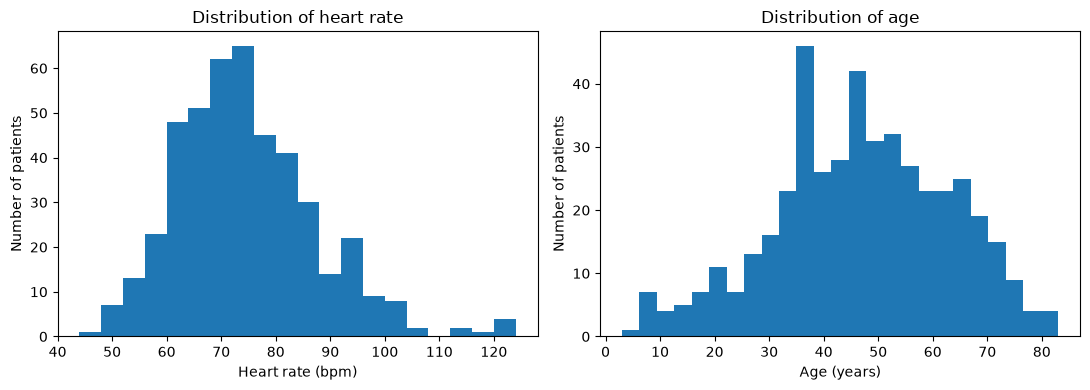

In [42]:
# Plot two cleaned distributions side by side.
# Deviation: combined panels replace separate figures; optional space saving.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_etl_clean["heart_rate"].dropna(), bins=20)
axes[0].set(
    title="Distribution of heart rate",
    xlabel="Heart rate (bpm)",
    ylabel="Number of patients",
)
axes[1].hist(df_etl_clean["age"].dropna(), bins=25)
axes[1].set(
    title="Distribution of age",
    xlabel="Age (years)",
    ylabel="Number of patients",
)
plt.tight_layout()
plt.show()


**What the result means:** the tallest bars locate common values; thinner bars extending away from the peak form the tails. An isolated bar may deserve investigation, but a histogram alone cannot establish that the underlying record is invalid.


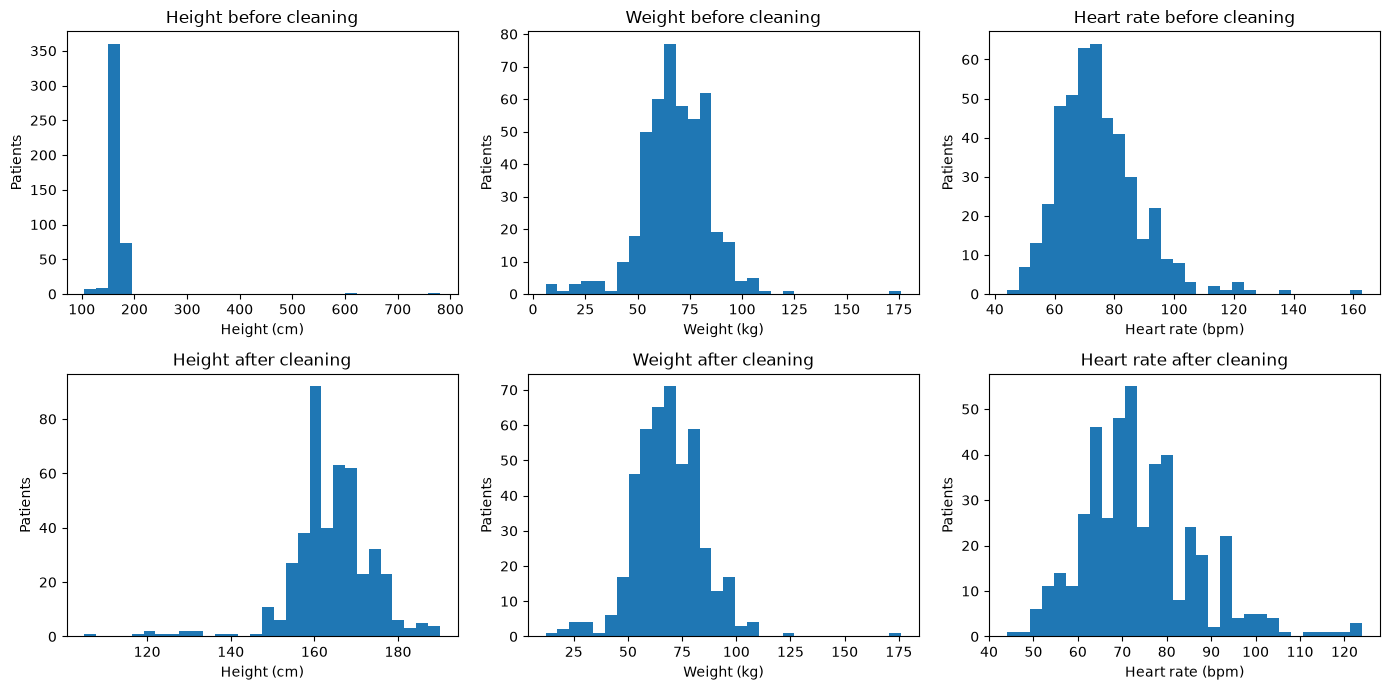

age: raw (np.int64(0), np.int64(83)); clean (np.int64(3), np.int64(83))
height: raw (np.int64(105), np.int64(780)); clean (np.int64(105), np.int64(190))
weight: raw (np.int64(6), np.int64(176)); clean (np.int64(12), np.int64(176))
heart_rate: raw (np.float64(44.0), np.float64(163.0)); clean (np.float64(44.0), np.float64(124.0))


In [43]:
# Define labels once for all three measurements.
plot_specs = [
    ("height", "Height", "cm"),
    ("weight", "Weight", "kg"),
    ("heart_rate", "Heart rate", "bpm"),
]

# Compare raw (top) and cleaned (bottom) plots.
# Deviation: one grid replaces six separate figures; optional.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for column_index, (column, label, unit) in enumerate(plot_specs):
    axes[0, column_index].hist(
        df_original[column].dropna(), bins=30
    )
    axes[0, column_index].set(
        title=f"{label} before cleaning",
        xlabel=f"{label} ({unit})",
        ylabel="Patients",
    )
    axes[1, column_index].hist(
        df_etl_clean[column].dropna(), bins=30
    )
    axes[1, column_index].set(
        title=f"{label} after cleaning",
        xlabel=f"{label} ({unit})",
        ylabel="Patients",
    )

plt.tight_layout()
plt.show()

for column in ["age", "height", "weight", "heart_rate"]:
    print(
        f"{column}: raw "
        f"{(df_original[column].min(), df_original[column].max())}; "
        f"clean "
        f"{(df_etl_clean[column].min(), df_etl_clean[column].max())}"
    )


**What the result means:** raw height runs from 105 to 780 cm, but cleaned height runs from 105 to 190 cm. Removing the impossible heights makes the main height distribution readable instead of compressing it into a narrow cluster. The weight minimum changes from 6 to 12 kg and the heart-rate maximum from 163 to 124 bpm because the four internally unreliable records were removed. Apart from those targeted records, the weight and heart-rate distributions remain broadly similar because statistically unusual values were not automatically deleted.

**Your task:** compare the raw and cleaned height, weight, and heart-rate plots. Identify peaks, tails, isolated bars, what changed, and what stayed similar.


## 8.3 — Boxplots and statistical outlier flags

In a boxplot, the box spans the middle 50%, the line is the median, whiskers extend to the most distant observations within the plotting rule, and points beyond them are flagged. IQR and z-score rules identify statistically unusual values; they are not automatic deletion rules.


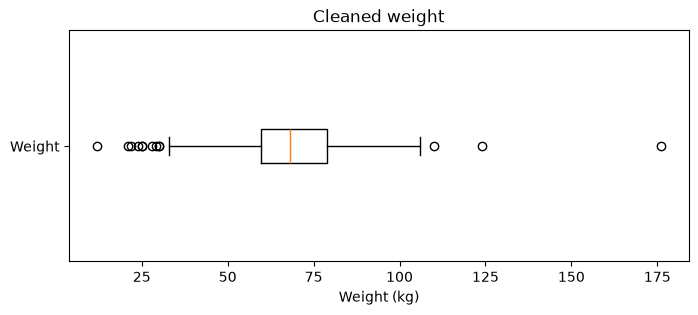

Demographic records flagged by at least one IQR rule:


,age,sex,height,weight,class
316,3,0,105,12,5
420,7,0,119,21,9
399,7,1,127,22,5
294,7,1,130,30,10
375,8,0,120,28,10
425,8,1,130,24,16
397,9,0,120,25,14
112,9,0,132,33,1
207,11,1,124,25,10
426,11,0,138,29,10


Heart-rate values with |z| > 3:


,age,sex,heart_rate,class
240,49,1,115.0,15
316,3,0,124.0,5
375,8,0,123.0,10
383,53,1,117.0,5
399,7,1,122.0,5
429,70,0,120.0,3


In [44]:
# Show the weight median, spread, and flagged points.
plt.figure(figsize=(8, 3))
plt.boxplot(
    df_etl_clean["weight"].dropna(),
    orientation="horizontal",  # Horizontal for easier reading.
    tick_labels=["Weight"],
)
plt.xlabel("Weight (kg)")
plt.title("Cleaned weight")
plt.show()


# Return True for values beyond 1.5 IQRs.
def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)


age_flag = iqr_flag(df_etl_clean["age"])
height_flag = iqr_flag(df_etl_clean["height"])
weight_flag = iqr_flag(df_etl_clean["weight"])
demographic_flags = age_flag | height_flag | weight_flag

print("Demographic records flagged by at least one IQR rule:")
display(
    df_etl_clean.loc[
        demographic_flags,
        ["age", "sex", "height", "weight", "class"],
    ].sort_values(["age", "height", "weight"])
)

mean_hr = df_etl_clean["heart_rate"].mean()
std_hr = df_etl_clean["heart_rate"].std()
z_hr = (df_etl_clean["heart_rate"] - mean_hr) / std_hr
print("Heart-rate values with |z| > 3:")
display(
    df_etl_clean.loc[
        z_hr.abs() > 3,
        ["age", "sex", "heart_rate", "class"],
    ]
)


**What the result means:** the 3-year-old record at 105 cm and 12 kg and the 7-year-old record at 119 cm and 21 kg are flagged by adult-dominated IQR ranges, but their age, height, and weight combinations are physically plausible for children. They should therefore be retained. The same principle applies to a high but physically possible adult weight: statistical distance from the sample centre is evidence for review, not proof of error.

**Your task:** identify at least two flagged but plausible records and explain why the IQR or z-score flag should not cause automatic deletion.


### Uncapped baseline

These three boxplots preserve the cleaned values. They are the baseline for the optional sensitivity analysis in the next task.


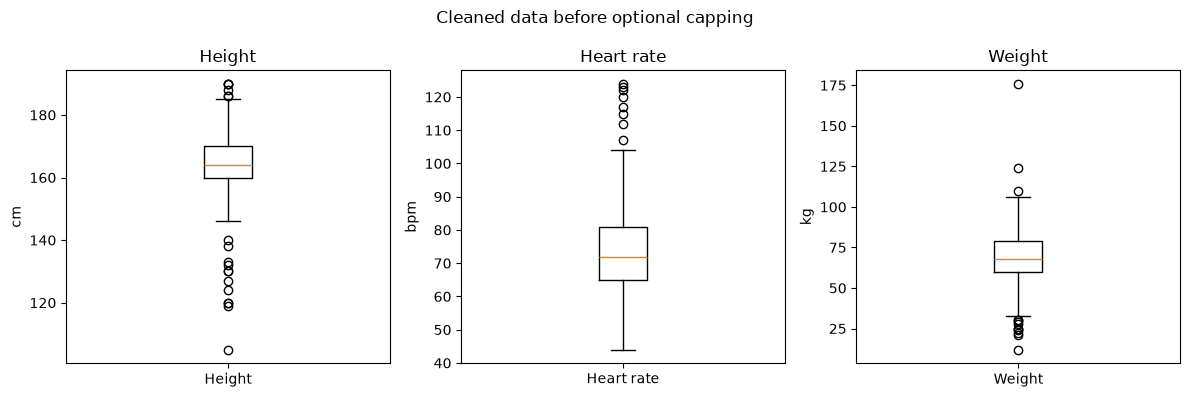

In [45]:
# Plot the uncapped baseline for later comparison.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, column, label, unit in zip(
    axes,
    ["height", "heart_rate", "weight"],
    ["Height", "Heart rate", "Weight"],
    ["cm", "bpm", "kg"],
):
    axis.boxplot(df_etl_clean[column].dropna(), tick_labels=[label])
    axis.set_title(label)
    axis.set_ylabel(unit)
plt.suptitle("Cleaned data before optional capping")
plt.tight_layout()
plt.show()


**What the result means:** these plots show the retained extremes rather than hiding them. Saving this baseline is essential because the capped view is a comparison, not a replacement dataset.


## 8.4 — Optional sensitivity-only capping

Capping replaces values beyond selected quantiles with the boundary value in a separate copy. It tests whether visual conclusions depend strongly on extremes; it does not prove those extremes are wrong.


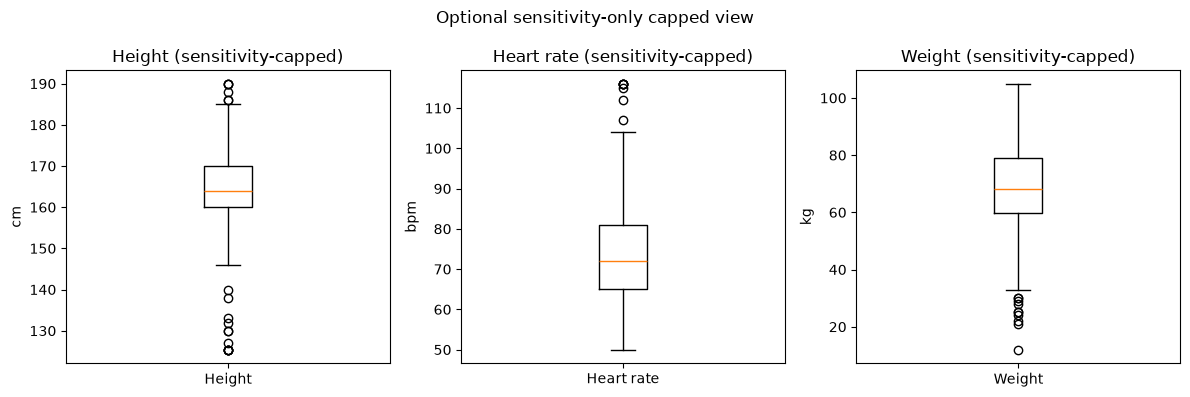

Main cleaned DataFrame unchanged: True


In [46]:
# Added check: prove capping leaves the main data unchanged.
# Optional safeguard, not required for the capping itself.
clean_fingerprint_before_capping = pd.util.hash_pandas_object(
    df_etl_clean, index=True
).sum()

# Cap values only in a separate sensitivity copy.
df_sensitivity = df_etl_clean.copy(deep=True)

df_sensitivity["height_capped"] = df_sensitivity["height"].clip(
    lower=df_sensitivity["height"].quantile(0.01)
)
df_sensitivity["heart_rate_capped"] = (
    df_sensitivity["heart_rate"].clip(
        lower=df_sensitivity["heart_rate"].quantile(0.01),
        upper=df_sensitivity["heart_rate"].quantile(0.99),
    )
)
df_sensitivity["weight_capped"] = df_sensitivity["weight"].clip(
    upper=df_sensitivity["weight"].quantile(0.99)
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, column, label, unit in zip(
    axes,
    ["height_capped", "heart_rate_capped", "weight_capped"],
    ["Height", "Heart rate", "Weight"],
    ["cm", "bpm", "kg"],
):
    axis.boxplot(df_sensitivity[column].dropna(), tick_labels=[label])
    axis.set_title(f"{label} (sensitivity-capped)")
    axis.set_ylabel(unit)
plt.suptitle("Optional sensitivity-only capped view")
plt.tight_layout()
plt.show()

clean_unchanged = (
    clean_fingerprint_before_capping
    == pd.util.hash_pandas_object(df_etl_clean, index=True).sum()
)
print("Main cleaned DataFrame unchanged:", clean_unchanged)
assert clean_unchanged


**What the result means:** capping shortens the displayed extremes and may change axis scale, but the central pattern should remain recognisable. `df_etl_clean` remains the main dataset because the capped values are artificial boundaries used only to test sensitivity.

**Your task:** state whether capping changes your visual interpretation and explain why the capped copy is not used as the main dataset.


## 8.5 — Group comparison and correlation heatmap

The bar chart compares observed binary-arrhythmia proportions by sex. The heatmap shows Pearson linear correlation among seven selected inputs; it does not summarise all 279 features and cannot establish causation.


Arrhythmia proportion by sex:
sex
Male      0.580
Female    0.355
Name: arrhythmia_present, dtype: float64


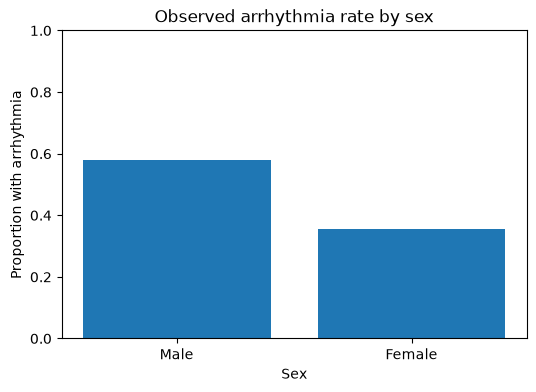

In [47]:
# Calculate the arrhythmia proportion for each sex.
rate = (
    df_etl_clean
    .groupby("sex", observed=False)["arrhythmia_present"]
    .mean()
)

# Replace numeric codes with readable labels.
sex_labels = {0: "Male", 1: "Female"}
labels = [sex_labels.get(int(value), str(value)) for value in rate.index]
print("Arrhythmia proportion by sex:")
print(rate.rename(index=sex_labels).round(3))

plt.figure(figsize=(6, 4))
plt.bar(labels, rate.values)
plt.ylim(0, 1)
plt.xlabel("Sex")
plt.ylabel("Proportion with arrhythmia")
plt.title("Observed arrhythmia rate by sex")
plt.show()


### Interpretation — arrhythmia rate by sex

**What the result means:** the observed arrhythmia proportion is 58.0% for males and 35.5% for females, so the male category is higher in this sample. This is an unadjusted sample association: it does not show that sex causes arrhythmia and it does not control for age or other clinical variables.

**Your task:** write one short paragraph interpreting the bar chart without making a causal claim.


,age,height,weight,qrs_duration,pr_interval,qt_interval,heart_rate
age,1.00,0.22,0.35,-0.01,0.03,0.14,-0.12
height,0.22,1.00,0.58,0.04,0.07,0.02,-0.18
weight,0.35,0.58,1.00,0.09,0.12,0.04,-0.08
qrs_duration,-0.01,0.04,0.09,1.00,0.02,0.22,0.01
pr_interval,0.03,0.07,0.12,0.02,1.00,0.07,-0.04
qt_interval,0.14,0.02,0.04,0.22,0.07,1.00,-0.62
heart_rate,-0.12,-0.18,-0.08,0.01,-0.04,-0.62,1.00


Strongest positive: ('height', 'weight') 0.58
Strongest negative: ('qt_interval', 'heart_rate') -0.62


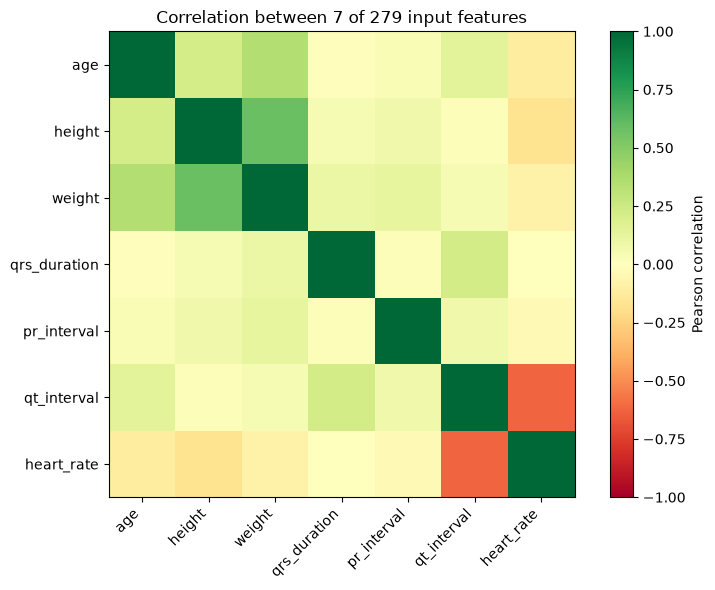

In [48]:
# Select seven interpretable numeric features.
num_cols = [
    "age", "height", "weight", "qrs_duration",
    "pr_interval", "qt_interval", "heart_rate",
]

# Calculate pairwise linear correlations.
corr_matrix = df_etl_clean[num_cols].corr()
display(corr_matrix.round(2))

# Ignore duplicate and self-correlations.
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Added calculation: answers the strongest-pair task directly; useful, not essential to plotting.
pairwise_correlations = upper_triangle.stack()
strongest_positive = pairwise_correlations.idxmax()
strongest_negative = pairwise_correlations.idxmin()
print(
    "Strongest positive:",
    strongest_positive,
    round(pairwise_correlations[strongest_positive], 2),
)
print(
    "Strongest negative:",
    strongest_negative,
    round(pairwise_correlations[strongest_negative], 2),
)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.xticks(
    range(len(num_cols)), num_cols, rotation=45, ha="right"
)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(label="Pearson correlation")
plt.title("Correlation between 7 of 279 input features")
plt.tight_layout()
plt.show()


### Interpretation — correlation heatmap

**What the result means:** among these seven features, height and weight have the strongest positive correlation (`r = 0.58`), while QT interval and heart rate have the strongest negative correlation (`r = -0.62`). Green cells are positive relationships, red cells are negative, and values near zero indicate little linear relationship. Correlation describes association, not cause, and can miss non-linear relationships.

**Your task:** write one short paragraph identifying the strongest positive and negative relationships and explaining why correlation does not prove causation.


## 8.6 — Arrhythmia-type profile and raw missingness

Class means must be read alongside class counts: a mean based on very few patients is unstable. Standardising each feature column places different measurement scales on a comparable colour scale.


Patients per class:
class
1     244
2      44
3      15
4      15
5      10
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64

Mean profile per class:


,p_interval,qrs_duration,pr_interval,qt_interval,t_interval,heart_rate
class,,,,,,
1,92.2,84.3,157.2,367.2,163.0,73.2
2,87.5,89.8,153.0,369.6,190.7,77.7
3,98.4,93.3,163.2,355.5,201.8,81.3
4,94.0,89.9,160.4,352.1,170.0,83.1
5,88.2,89.6,164.5,311.9,156.8,106.9
6,80.0,83.2,158.0,393.2,152.9,53.9
7,98.0,96.3,190.7,365.3,185.3,73.7
8,101.5,98.5,183.0,368.0,185.0,66.0
9,90.3,154.4,158.4,439.4,263.7,67.4


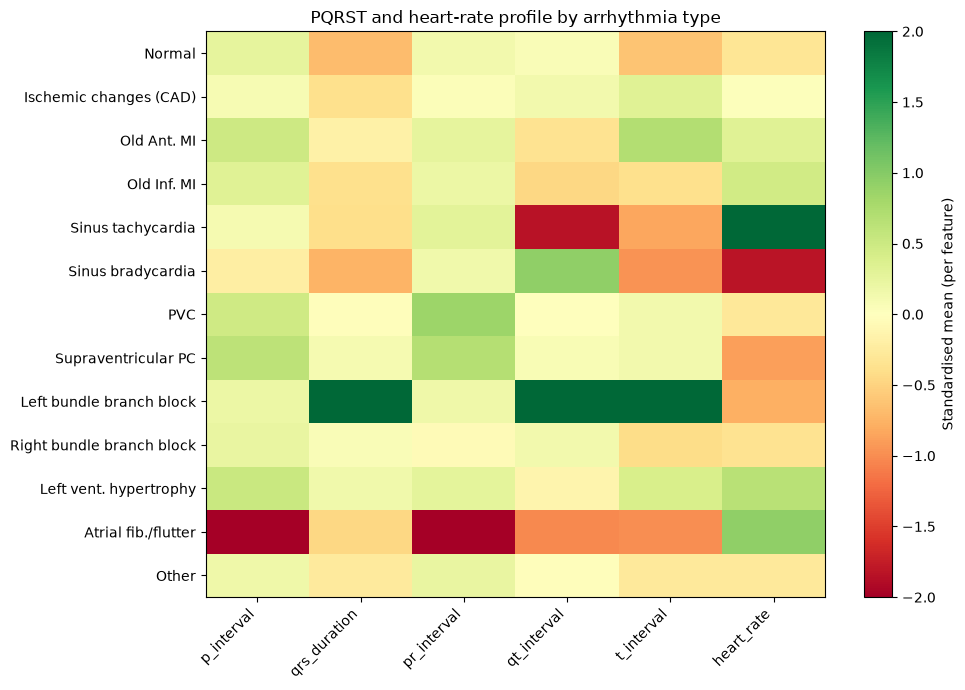

In [49]:
# Map diagnosis codes to readable names.
class_names = {
    1: "Normal",
    2: "Ischemic changes (CAD)",
    3: "Old Ant. MI",
    4: "Old Inf. MI",
    5: "Sinus tachycardia",
    6: "Sinus bradycardia",
    7: "PVC",
    8: "Supraventricular PC",
    9: "Left bundle branch block",
    10: "Right bundle branch block",
    11: "1st degree AV block",
    12: "2nd degree AV block",
    13: "3rd degree AV block",
    14: "Left vent. hypertrophy",
    15: "Atrial fib./flutter",
    16: "Other",
}
# Choose timing and heart-rate features.
pqrst_cols = [
    "p_interval", "qrs_duration", "pr_interval",
    "qt_interval", "t_interval", "heart_rate",
]

# Count patients before interpreting class means.
class_counts = df_etl_clean["class"].value_counts().sort_index()
print("Patients per class:")
print(class_counts)

profile = df_etl_clean.groupby("class")[pqrst_cols].mean()
print("\nMean profile per class:")
display(profile.round(1))

profile_z = (profile - profile.mean()) / profile.std()
row_labels = [class_names[int(value)] for value in profile_z.index]
plt.figure(figsize=(10, 7))
plt.imshow(
    profile_z.values,
    cmap="RdYlGn",
    vmin=-2,
    vmax=2,
    aspect="auto",
)
plt.xticks(
    range(len(pqrst_cols)), pqrst_cols, rotation=45, ha="right"
)
plt.yticks(range(len(profile_z)), row_labels)
plt.colorbar(label="Standardised mean (per feature)")
plt.title("PQRST and heart-rate profile by arrhythmia type")
plt.tight_layout()
plt.show()


**What the result means:** sinus tachycardia (class 5) has the highest mean heart rate at about 106.9 bpm and a relatively short mean QT interval of 311.9. Sinus bradycardia (class 6) has the lowest mean heart rate at about 53.9 bpm and a longer mean QT interval of 393.2. Left bundle branch block (class 9) stands out with mean QRS duration 154.4, QT interval 439.4, and T interval 263.7. Within each feature column green is above the across-class mean and red is below it, but interpretation must use the class counts: classes 7 and 8 contain only three and two records, so their apparent patterns are especially unstable.

**Your task:** describe three notable class-profile patterns and one limitation of interpreting this heatmap.


Raw missingness (%):
j_angle       83.19
p_angle        4.87
t_angle        1.77
heart_rate     0.22
qrst_angle     0.22
dtype: float64


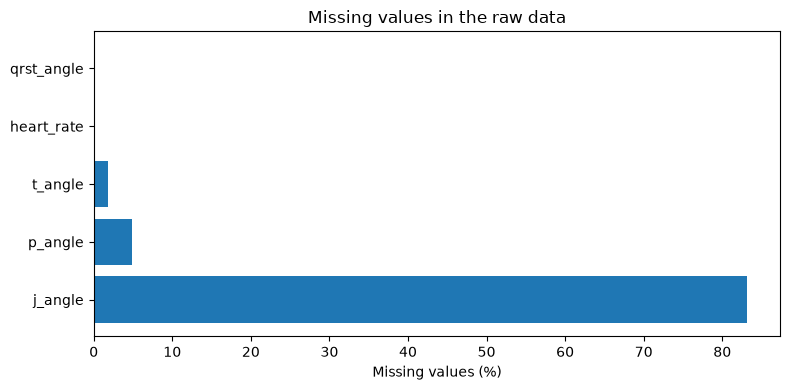

Greatest missingness: j_angle (83.19%)


In [50]:
# Calculate raw missing percentages, largest first.
# Added printout identifies the maximum directly; required by Task 40.
missing_percent = (
    df_original.isna().mean().sort_values(ascending=False)
)
missing_percent = missing_percent[missing_percent > 0] * 100
print("Raw missingness (%):")
print(missing_percent.round(2))

plt.figure(figsize=(8, 4))
plt.barh(missing_percent.index.astype(str), missing_percent.values)
plt.xlabel("Missing values (%)")
plt.title("Missing values in the raw data")
plt.tight_layout()
plt.show()

print(
    "Greatest missingness:",
    missing_percent.index[0],
    f"({missing_percent.iloc[0]:.2f}%)",
)


**What the result means:** `j_angle` has the greatest raw missingness at 83.19%, far above `p_angle` at 4.87% and the remaining incomplete columns. This supports dropping `j_angle` under the documented cleaning plan. Missingness is analysed on `df_original` because the cleaned table has already imputed selected columns and removed `j_angle`.


## 8.7 — Scatter plots and pair plot

Scatter plots show individual observations and overlap that group averages can hide. Start with heart rate by diagnosis class.


Mean heart rate by class:
class
6      53.9
8      66.0
9      67.4
10     72.8
1      73.2
7      73.7
16     73.9
2      77.7
3      81.3
4      83.1
14     85.5
15     89.2
5     106.9
Name: heart_rate, dtype: float64


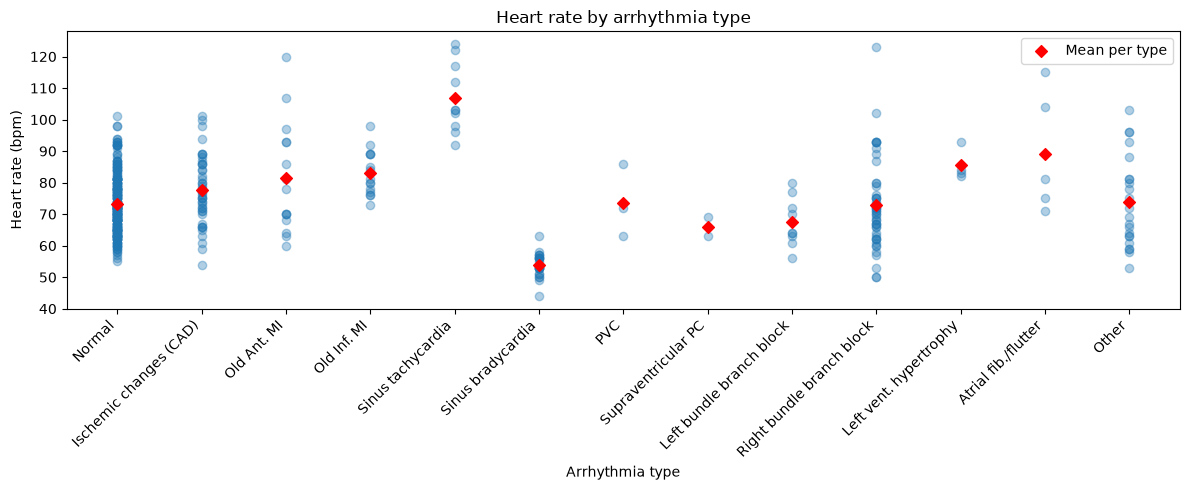

In [51]:
# Place diagnosis classes in numeric order.
order = sorted(df_etl_clean["class"].unique())
x_positions = df_etl_clean["class"].map(
    {value: position for position, value in enumerate(order)}
)

# Calculate one heart-rate mean per class.
means = df_etl_clean.groupby("class")["heart_rate"].mean()
print("Mean heart rate by class:")
print(means.sort_values().round(1))

plt.figure(figsize=(12, 5))
plt.scatter(x_positions, df_etl_clean["heart_rate"], alpha=0.35)
plt.scatter(
    range(len(order)),
    [means[value] for value in order],
    color="red",
    marker="D",
    label="Mean per type",
)
plt.xticks(
    range(len(order)),
    [class_names[value] for value in order],
    rotation=45,
    ha="right",
)
plt.xlabel("Arrhythmia type")
plt.ylabel("Heart rate (bpm)")
plt.title("Heart rate by arrhythmia type")
plt.legend()
plt.tight_layout()
plt.show()


**What the result means:** sinus tachycardia (class 5) has the highest sample mean heart rate at 106.9 bpm, while sinus bradycardia (class 6) has the lowest at 53.9 bpm. The individual points still show within-class spread and overlap, so a class average does not describe every patient in that class.

**Your task:** write two or three sentences identifying the highest and lowest class means and describing the within-class spread.


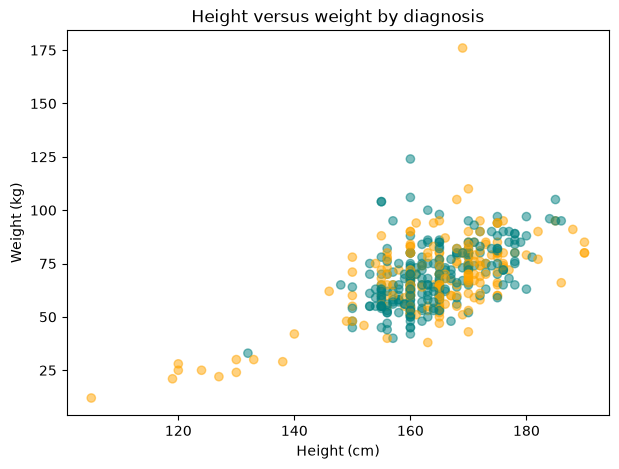

In [52]:
# Colour points by binary diagnosis.
colors = df_etl_clean["arrhythmia_present"].map(
    {True: "orange", False: "teal"}
)

# Plot height against weight.
plt.figure(figsize=(7, 5))
plt.scatter(
    df_etl_clean["height"],
    df_etl_clean["weight"],
    c=colors,
    alpha=0.5,
)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height versus weight by diagnosis")
plt.show()


**What the result means:** height and weight have a positive relationship, but the diagnosis colours overlap heavily. These two measurements alone do not visually separate normal records from arrhythmia records.

**Your task:** write two or three sentences describing the relationship and the overlap between diagnosis groups.


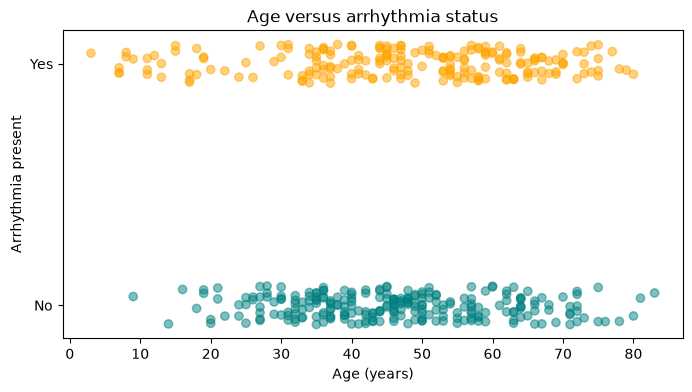

In [53]:
# Add small offsets so overlapping binary points show.
# Deviation: the seeded generator makes the plot repeatable; optional.
jitter = (
    df_etl_clean["arrhythmia_present"].astype(int)
    + rng.uniform(-0.08, 0.08, len(df_etl_clean))
)
plt.figure(figsize=(8, 4))
plt.scatter(
    df_etl_clean["age"],
    jitter,
    c=colors,
    alpha=0.5,
)
plt.yticks([0, 1], ["No", "Yes"])
plt.xlabel("Age (years)")
plt.ylabel("Arrhythmia present")
plt.title("Age versus arrhythmia status")
plt.show()


**What the result means:** jitter adds small vertical offsets so overlapping binary points can be seen; it does not alter age or diagnosis. The age ranges overlap substantially, so age alone is not a perfect separator.

**Your task:** write two or three sentences explaining the jitter and what the overlap says about age as a standalone separator.


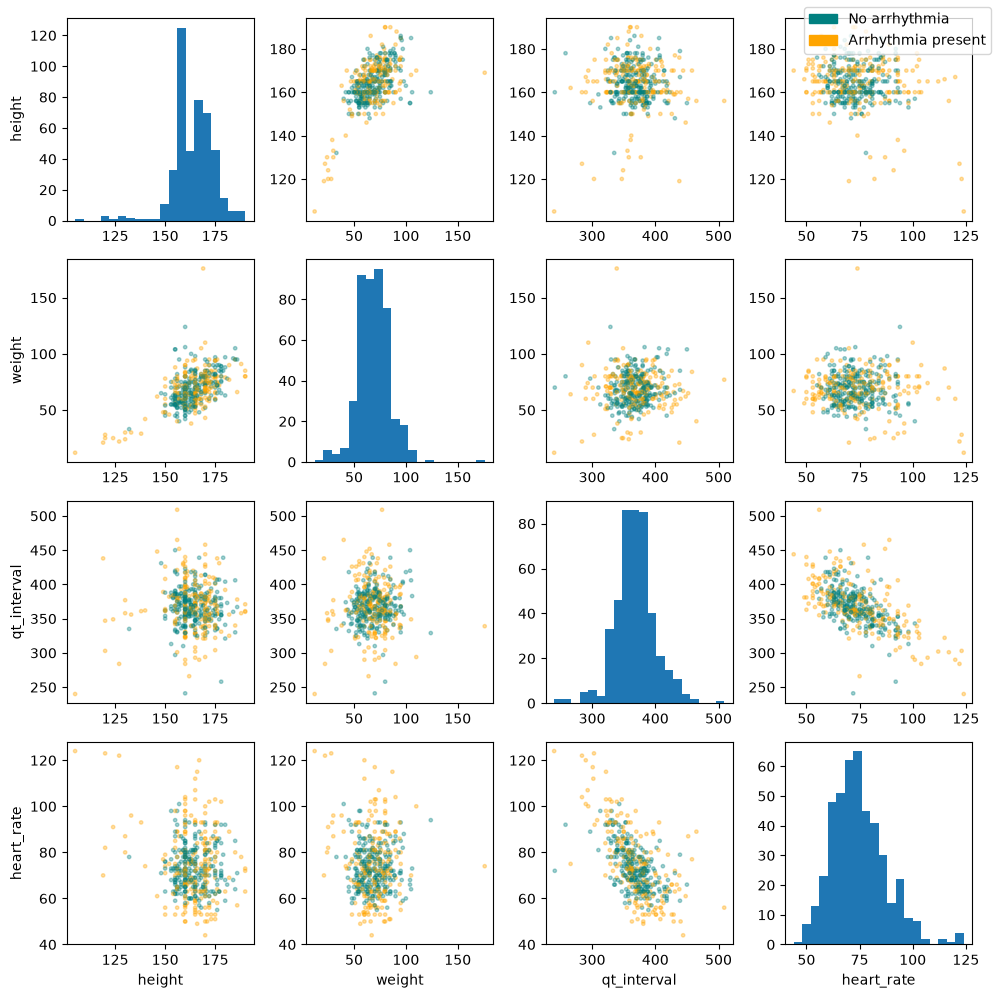

In [54]:
# Build legend colour patches.
from matplotlib.patches import Patch

# Create a Matplotlib pair-plot grid.
pair_cols = ["height", "weight", "qt_interval", "heart_rate"]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

# Histograms on diagonal; scatter plots elsewhere.
for row_index, row_column in enumerate(pair_cols):
    for column_index, column_column in enumerate(pair_cols):
        axis = axes[row_index, column_index]
        if row_index == column_index:
            axis.hist(df_etl_clean[row_column].dropna(), bins=20)
        else:
            axis.scatter(
                df_etl_clean[column_column],
                df_etl_clean[row_column],
                s=6,
                alpha=0.35,
                c=colors,
            )
        if row_index == len(pair_cols) - 1:
            axis.set_xlabel(column_column)
        if column_index == 0:
            axis.set_ylabel(row_column)

fig.legend(
    handles=[
        Patch(color="teal", label="No arrhythmia"),
        Patch(color="orange", label="Arrhythmia present"),
    ],
    loc="upper right",
)
plt.tight_layout()
plt.show()


**What the result means:** the diagonal contains one-variable distributions; the other panels show pairwise relationships. Height and weight tend to increase together, while QT interval and heart rate tend to move in opposite directions. Diagnosis colours still overlap, showing why multivariable analysis is needed.

**Your task:** write a short overall conclusion about the strongest pairwise patterns and the diagnosis-group overlap.


## 8.8 — Population, sample, parameter, and statistic

- **Population:** all patients about whom the research question aims to draw conclusions.
- **Sample:** the patient records retained after the documented cleaning rules.
- **Parameter:** an unknown true numerical property of the population.
- **Statistic:** a number calculated from the sample to estimate a parameter.


In [55]:
# Calculate a sample statistic: mean age.
# Added sample size gives context; optional.
sample_mean_age = df_etl_clean["age"].mean()
print("Cleaned sample size:", len(df_etl_clean))
print(f"Sample mean age: {sample_mean_age:.2f} years")


Cleaned sample size: 448
Sample mean age: 46.75 years


**What the result means:** the sample mean is known for these retained records, but it is only an estimate of the unknown population mean. Sampling, inclusion criteria, data quality, and cleaning choices can all make it differ from the wider population value.

**Your task:** explain in your own words why the sample mean is an estimate rather than the true population mean.


# Lab 3 — Part C: Statistical testing

For both tests, use `alpha = 0.05`.

- `H0` (null hypothesis) states no population difference or association.
- `H1` (alternative hypothesis) states a population difference or association.
- If `p < 0.05`, reject `H0`; otherwise, fail to reject `H0`.

Failing to reject `H0` does **not** prove that `H0` is true.


## 9.1 — Welch independent-samples t-test

**Question:** is mean heart rate different between records with and without arrhythmia?

- `H0`: the two population mean heart rates are equal.
- `H1`: the two population mean heart rates differ.

Welch's test is used because it does not assume equal group variances.


In [56]:
# Split heart rate into two independent groups.
with_arrhythmia = df_etl_clean.loc[
    df_etl_clean["arrhythmia_present"], "heart_rate"
]
without_arrhythmia = df_etl_clean.loc[
    ~df_etl_clean["arrhythmia_present"], "heart_rate"
]

# Welch test: does not assume equal variances.
t_statistic, p_value = stats.ttest_ind(
    with_arrhythmia,
    without_arrhythmia,
    equal_var=False,
)

print(f"Mean with arrhythmia: {with_arrhythmia.mean():.2f}")
print(f"Mean without arrhythmia: {without_arrhythmia.mean():.2f}")
print(f"t = {t_statistic:.2f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("Decision: reject H0.")
    print("Evidence of a difference in population mean heart rate.")
else:
    print("Decision: fail to reject H0.")
    print("No statistically significant mean difference was detected.")


Mean with arrhythmia: 75.08
Mean without arrhythmia: 73.21
t = 1.46, p = 0.1441
Decision: fail to reject H0.
No statistically significant mean difference was detected.


**What the result means:** mean heart rate is 75.08 bpm with arrhythmia and 73.21 bpm without arrhythmia. Welch's test gives `t = 1.46` and `p = 0.1441`; because `p > 0.05`, we fail to reject `H0`. The sample does not provide statistically significant evidence that the population mean heart rates differ. This does not prove that the two population means are identical.

**Your task:** report both group means, `t`, `p`, the decision about `H0`, and a plain-language conclusion without claiming the means are identical.


## 9.2 — Chi-square test of independence

**Question:** are recorded sex and binary arrhythmia status associated?

- `H0`: sex and arrhythmia status are independent in the population.
- `H1`: sex and arrhythmia status are associated.

The contingency table contains counts, not averages. The test compares observed counts with counts expected under independence.


In [57]:
# Count each sex-by-diagnosis combination.
contingency_table = pd.crosstab(
    df_etl_clean["sex"],
    df_etl_clean["arrhythmia_present"],
)
print("Observed counts:")
display(
    contingency_table.rename(
        index={0: "Male", 1: "Female"},
        columns={False: "No arrhythmia", True: "Arrhythmia"},
    )
)

# Added percentages: required by the task, absent from its supplied code.
arrhythmia_percent = (
    contingency_table[True]
    / contingency_table.sum(axis=1)
    * 100
)
print("Arrhythmia percentage by sex:")
print(arrhythmia_percent.rename(index={0: "Male", 1: "Female"}).round(2))

# Test whether the two categorical variables are independent.
chi_square, p_value, degrees_freedom, expected = (
    stats.chi2_contingency(contingency_table)
)
print(f"chi-square = {chi_square:.2f}, p = {p_value:.6f}")
print("Degrees of freedom:", degrees_freedom)
print("Expected counts under H0:")
display(
    pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns,
    ).round(2)
)

if p_value < 0.05:
    print("Decision: reject H0.")
    print("Sex and arrhythmia status are associated in this sample.")
else:
    print("Decision: fail to reject H0.")
    print("No statistically significant association was detected.")


Observed counts:


arrhythmia_present,No arrhythmia,Arrhythmia
sex,,
Male,84,116
Female,160,88


Arrhythmia percentage by sex:
sex
Male      58.00
Female    35.48
dtype: float64
chi-square = 21.73, p = 0.000003
Degrees of freedom: 1
Expected counts under H0:


arrhythmia_present,False,True
sex,,
0,108.93,91.07
1,135.07,112.93


Decision: reject H0.
Sex and arrhythmia status are associated in this sample.


**What the result means:** arrhythmia is present in 58.00% of male records and 35.48% of female records. The test gives `chi-square = 21.73`, one degree of freedom, and `p = 0.000003`; because `p < 0.05`, we reject independence and conclude that sex and arrhythmia status are associated in this sample. The result does not show that sex causes arrhythmia, and the percentages should not be treated as universal population rates.

**Your task:** calculate and report each percentage, chi-square, `p`, the decision about `H0`, and a non-causal plain-language conclusion.


## 9.3 — Final worked-example check

Before showing or submitting the notebook:

1. Restart the kernel and run every cell from top to bottom.
2. Confirm there are no error outputs or variables that depend on a hidden earlier run.
3. Keep useful outputs and add your own brief interpretations to the **Your task** prompts.
4. Confirm `df_original` is still `452 × 280` and `df_etl_clean` is `448 × 281`.
5. Save a submission copy with your name or group number if required.
6. Submit and show the complete worked-example notebook to the teaching assistant as instructed.


In [58]:
# Added final checks: optional safeguards for Run All.
final_checks = {
    "raw_shape_is_452_by_280": df_original.shape == (452, 280),
    "clean_shape_is_448_by_281": df_etl_clean.shape == (448, 281),
    "raw_copy_is_unchanged": (
        raw_fingerprint
        == pd.util.hash_pandas_object(df_original, index=True).sum()
    ),
    "analysis_uses_binary_target": (
        "arrhythmia_present" in df_etl_clean.columns
    ),
}
print(pd.Series(final_checks, name="Passed"))
assert all(final_checks.values())


raw_shape_is_452_by_280        True
clean_shape_is_448_by_281      True
raw_copy_is_unchanged          True
analysis_uses_binary_target    True
Name: Passed, dtype: bool


**What the result means:** every check must print `True`. This is a compact integrity check, not a substitute for reading all preceding outputs and charts.


# Assessment 1 preparation — Steps 10–12

This section prepares the assessment without inventing personal details or claiming actions outside the notebook.

## Step 10 — Define the problem and select a dataset

Complete these fields in your own words:

- **Proposed project title:** `[enter title]`
- **Group members:** `[enter names; maximum three students]`
- **Real-world problem:** `[what needs to be understood or improved?]`
- **Motivation and practical relevance:** `[why does it matter?]`
- **Stakeholders:** `[who is affected or will use the result?]`
- **Analytical objective:** `[classification, prediction, clustering, anomaly detection, or forecasting]`

### Dataset suitability template

| Check | Your evidence |
|---|---|
| Dataset name and source | `[enter name and full URL]` |
| Tabular and alpha-numeric | `[confirm; images are not permitted]` |
| Initial feature count | `[must be more than 20 and fewer than 300]` |
| Record count | `[justify enough for exploration, training, validation, and testing]` |
| Target or analytical objective | `[state a meaningful, feasible target/task]` |
| Documentation and metadata | `[link and summary]` |
| Licence/access terms | `[state terms]` |
| Access date | `[enter date]` |

> Start with a meaningful problem, then select data capable of answering it. Do not choose a dataset only because it is convenient.


## Step 11 — Seek dataset approval through Canvas

Before detailed project development:

- open **Canvas → Assessments → Project Phase 1 → Approval form**;
- enter group members, project title, problem, dataset name, full plain-text link, and source;
- provide record and feature counts, target/task, and a brief justification;
- check whether another group has selected the same dataset where this is visible;
- submit the form and record the actual approval status below.

**Approval form submitted:** `[Yes/No — complete this yourself]`  
**Lecturer approval status:** `[Pending/Approved/Changes requested]`

Submitting the form and receiving approval are external actions and cannot be verified by this notebook.


## Step 12 — Start the Assessment 1 draft

Create a **separate notebook** for the approved project. Adapt the process rather than copying Arrhythmia-specific thresholds.

### Suggested draft sequence

1. Record title, group, problem, motivation, stakeholders, and objective.
2. Document dataset name, source, direct link, access date, licence, and documentation.
3. Load the data and immediately create an untouched deep copy.
4. Inspect shape, columns, types, categories, missingness, duplicates, and ranges.
5. Investigate unusual values using domain evidence.
6. Propose and justify dataset-specific cleaning rules.
7. Create a reusable cleaning function or documented pipeline plan.
8. Produce at least two preliminary quality/exploration charts.
9. Interpret every retained output in your own words.

Phase 1 covers problem formulation, acquisition, inspection, cleaning, and exploratory analysis. Machine-learning modelling is not required.

### Safe starter pattern for the separate assessment notebook

```python
import pandas as pd

df = pd.read_csv("your_approved_dataset.csv")
df_original = df.copy(deep=True)

print("Shape:", df_original.shape)
display(df_original.head())
print(df_original.dtypes)
print(df_original.isna().sum().sort_values(ascending=False).head(20))
print("Duplicate rows:", df_original.duplicated().sum())
```

This is shown as a markdown template so the completed Arrhythmia notebook still runs from top to bottom without requiring a dataset that has not yet been chosen.


## End-of-lab draft submission checklist

The Week 2 draft belongs under the Lab 2 assessment and the Week 3 draft under the Lab 3 assessment. Before leaving, confirm the draft:

- [ ] opens correctly;
- [ ] contains group-member names and the proposed title;
- [ ] explains the problem and practical relevance;
- [ ] documents source, licence, metadata, and suitability;
- [ ] records that the Canvas approval form was submitted;
- [ ] includes initial loading and inspection code;
- [ ] reports types, missingness, duplicates, ranges, and unusual values;
- [ ] proposes justified cleaning and transformation strategies;
- [ ] includes at least two preliminary charts with interpretations;
- [ ] lists next actions after approval;
- [ ] has actually been submitted successfully.

These boxes remain intentionally unticked until you personally complete and verify each action.
